
# TI-support-RAG — Parcial 1

## Objetivo

Demostrar, en una ejecución reproducible, el flujo del prototipo de Mesa de Ayuda TI:

**entrada → prompt → modelo → salida estructurada → validación → decisión → evidencia**

La implementación separa las responsabilidades en capas:

```text
Notebook
   │
   ├── configuración / experimentación / métricas
   │
   ├── OCR
   │      └── OCRFactory → OCRExtractor → OCRStrategy
   │                              ├── EasyOCR
   │                              └── Tesseract
   │
   ├── modelo
   │      └── Groq
   │
   └── evidencia
          └── PDFReport
```

> **Principio:** el modelo propone; el programa comprueba; el sistema decide.



## 0. Problema, usuario y alcance

### Problema

La Mesa de Ayuda TI recibe solicitudes con distintos niveles de claridad, información incompleta y, en algunos casos, contenido fuera del servicio o instrucciones no confiables. El prototipo transforma cada solicitud en una clasificación estructurada y controlada para facilitar su atención sin inventar datos.

### Usuario objetivo

La persona que reporta o aclara una situación relacionada con soporte de tecnologías de información y puede aportar una captura como evidencia.

### Alcance

- Clasificación en `hardware`, `software`, `redes`, `cuentas`, `seguridad`, `acceso` u `otros`.
- Prioridad controlada (`baja`, `media`, `alta`).
- Identificación de datos faltantes sin solicitar secretos.
- Derivación a intervención humana cuando corresponde.
- Entrada multimodal mediante OCR.
- Validación local de la salida del modelo.
- Registro consolidado de casos de prueba, OCR y defensa en un único PDF.

### Fuera de alcance

El prototipo no cambia configuraciones ni cuentas, no procesa secretos y no afirma realizar interpretación visual general de imágenes. El OCR extrae texto visible para incorporarlo como evidencia.



## Evidencias del parcial

El notebook reúne:

- configuración y prompt versionado;
- payload efectivo;
- validación estructural;
- decisión local;
- cinco casos reales;
- métricas de latencia y tokens;
- pruebas de la capa OCR;
- evidencia multimodal;
- mocks;
- consultas directas durante la defensa;
- un único registro PDF acumulativo.

El PDF ya no se genera desde un módulo especializado en resultados del modelo. El notebook registra la evidencia en `PDFReport` y el módulo de reporte se limita a almacenarla y presentarla.


In [1]:

from pathlib import Path
import json
import sys
import time
import shutil
import tempfile
from datetime import datetime, timezone

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()

for path in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (path / "src").is_dir() and (path / "prompts").is_dir():
        PROJECT_ROOT = path
        break
else:
    raise FileNotFoundError("No se encontró la raíz de TI-support-RAG.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    find_latest_prompt,
    MODEL,
    API_URL,
    TEST_PATH,
)
from src.groq_client import call_groq, build_payload, HTTP_TIMEOUT
from src.validator import validate_output
from src.mocks import mock_response

from src.multimodal import prepare_multimodal_input

from src.ocr import OCRExtractor, OCRFactory
from src.ocr.constants import SUPPORTED_IMAGE_EXTENSIONS
from src.ocr.exceptions import OCRInputError

from src.pdf_report import PDFReport

PROMPTS_DIR = PROJECT_ROOT / "prompts"
PROMPT_VERSION, PROMPT_PATH = find_latest_prompt(PROMPTS_DIR)
SYSTEM_PROMPT = PROMPT_PATH.read_text(encoding="utf-8")

test_cases = json.loads(TEST_PATH.read_text(encoding="utf-8"))

assert isinstance(test_cases, list)
assert all({"id", "tipo", "input", "expected"} <= set(case) for case in test_cases)

REPORT_PATH = PROJECT_ROOT / "docs" / "model_results_report.pdf"

report = PDFReport(REPORT_PATH)

print(f"Proyecto : {PROJECT_ROOT}")
print(f"Modelo   : {MODEL}")
print(f"Prompt   : {PROMPT_VERSION}")
print(f"Archivo  : {PROMPT_PATH.name}")
print(f"Casos    : {len(test_cases)}")
print(f"Endpoint : {API_URL}")
print(f"Timeout  : {HTTP_TIMEOUT}")


Proyecto : /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG
Modelo   : openai/gpt-oss-20b
Prompt   : system_v4
Archivo  : system_v4.md
Casos    : 5
Endpoint : https://api.groq.com/openai/v1/chat/completions
Timeout  : (10, 60)



## 1. Prompt activo

La versión se descubre dinámicamente mediante `find_latest_prompt()`. El notebook no depende de un número de versión escrito manualmente.


In [2]:

print(f"Archivo: {PROMPT_PATH.name}")
print(SYSTEM_PROMPT)


Archivo: system_v4.md
Eres un asistente de Mesa de Ayuda TI.

Analiza la solicitud del usuario y determina:

- categoria: hardware, software, redes, cuentas, seguridad, acceso u otros.
- prioridad: baja, media o alta.
- resumen de la solicitud.
- datos_faltantes relevantes y seguros.
- si requiere intervención humana.
- confianza de la clasificación entre 0 y 1.

No inventes información ni infieras sin evidencia:
- sistemas;
- servicios;
- aplicaciones;
- cuentas;
- dispositivos;
- causas;
- mensajes de error;
- impacto;
- urgencia.

Utiliza únicamente la información explícitamente proporcionada por el usuario para determinar la categoría y prioridad. Una afirmación explícita del usuario puede utilizarse como evidencia, pero no debes agregar información que no haya proporcionado.

Si la solicitud es ambigua o no existe evidencia suficiente para una categoría específica, utiliza "otros".

REGLA SOBRE SOLICITUDES INCOMPLETAS:

Si la solicitud no proporciona información suficiente para co


## 2. Payload enviado al modelo

Se inspecciona la estructura que prepara la aplicación para Groq antes de ejecutar un caso real.


In [3]:

payload = build_payload(
    SYSTEM_PROMPT,
    "Solicitud de prueba para inspeccionar la estructura del mensaje."
)

print("Modelo:", payload["model"])
print("Temperatura:", payload["temperature"])
print("Máximo de tokens:", payload["max_completion_tokens"])
print("Schema:", payload["response_format"]["json_schema"]["name"])

print("\nMensajes:")
for message in payload["messages"]:
    preview = message["content"]
    if message["role"] == "user":
        preview = preview[:180]
    print(f"- {message['role']}: {preview}")


Modelo: openai/gpt-oss-20b
Temperatura: 0
Máximo de tokens: 1500
Schema: solicitud_ti

Mensajes:
- system: Eres un asistente de Mesa de Ayuda TI.

Analiza la solicitud del usuario y determina:

- categoria: hardware, software, redes, cuentas, seguridad, acceso u otros.
- prioridad: baja, media o alta.
- resumen de la solicitud.
- datos_faltantes relevantes y seguros.
- si requiere intervención humana.
- confianza de la clasificación entre 0 y 1.

No inventes información ni infieras sin evidencia:
- sistemas;
- servicios;
- aplicaciones;
- cuentas;
- dispositivos;
- causas;
- mensajes de error;
- impacto;
- urgencia.

Utiliza únicamente la información explícitamente proporcionada por el usuario para determinar la categoría y prioridad. Una afirmación explícita del usuario puede utilizarse como evidencia, pero no debes agregar información que no haya proporcionado.

Si la solicitud es ambigua o no existe evidencia suficiente para una categoría específica, utiliza "otros".

REGLA SOBRE SO


## 3. Contrato y validación de salida

La aplicación acepta únicamente la estructura definida por el contrato y valida localmente la respuesta antes de determinar un estado.


In [4]:

valid_example = {
    "categoria": "hardware",
    "prioridad": "alta",
    "resumen": "El equipo no enciende al intentar iniciar.",
    "datos_faltantes": ["Modelo del equipo"],
    "requiere_humano": True,
    "confianza": 0.91,
}

invalid_example = {
    "categoria": "categoria_invalida",
    "prioridad": "alta",
    "resumen": "Problema",
    "datos_faltantes": [],
    "requiere_humano": "si",
    "confianza": "0.91",
    "campo_extra": True,
}

ERROR_LABEL = "Errores:"
ok_valid, valid_errors, _ = validate_output(valid_example)
ok_invalid, invalid_errors, _ = validate_output(invalid_example)

print("Salida válida:", ok_valid)
print(ERROR_LABEL, valid_errors)

print("\nSalida inválida:", ok_invalid)
for error in invalid_errors:
    print("-", error)

assert ok_valid and not ok_invalid


Salida válida: True
Errores: []

Salida inválida: False
- categoria: Input should be 'hardware', 'software', 'redes', 'cuentas', 'seguridad', 'acceso' or 'otros'
- resumen: String should have at least 10 characters
- requiere_humano: Input should be a valid boolean
- campo_extra: Extra inputs are not permitted



## 4. Decisión local

Una salida estructuralmente válida todavía pasa por reglas deterministas de la aplicación.


In [5]:

CLARIFICATION_THRESHOLD = 0.60

def determine_state(output: dict) -> str:
    if output["requiere_humano"]:
        return "OK_REQUIERE_HUMANO"
    if output["confianza"] < CLARIFICATION_THRESHOLD or output["datos_faltantes"]:
        return "OK_PIDE_ACLARACION"
    return "OK_VALIDADO"


decision_checks = [
    ({"requiere_humano": True, "confianza": 0.99, "datos_faltantes": []}, "OK_REQUIERE_HUMANO"),
    ({"requiere_humano": False, "confianza": 0.40, "datos_faltantes": []}, "OK_PIDE_ACLARACION"),
    ({"requiere_humano": False, "confianza": 0.90, "datos_faltantes": ["Sistema"]}, "OK_PIDE_ACLARACION"),
    ({"requiere_humano": False, "confianza": 0.90, "datos_faltantes": []}, "OK_VALIDADO"),
]

for sample, expected in decision_checks:
    observed = determine_state(sample)
    print(observed)
    assert observed == expected


OK_REQUIERE_HUMANO
OK_PIDE_ACLARACION
OK_PIDE_ACLARACION
OK_VALIDADO



## 5. Capa OCR

El notebook ya no implementa OCR directamente. Solo consume la abstracción pública:

**`OCRFactory → OCRExtractor → OCRStrategy`**

Los motores intercambiables son `EasyOCR` y `Tesseract`.


In [6]:

OCR_ENGINES = OCRFactory.supported_engines()

print("Motores registrados:", OCR_ENGINES)
print("Extensiones soportadas:", ", ".join(sorted(SUPPORTED_IMAGE_EXTENSIONS)))

assert "easyocr" in OCR_ENGINES
assert "tesseract" in OCR_ENGINES


Motores registrados: ('easyocr', 'tesseract')
Extensiones soportadas: .bmp, .jpeg, .jpg, .png, .tif, .tiff, .webp


In [7]:

# Prueba de validación de entrada delegada a la capa OCR.
with tempfile.TemporaryDirectory() as temp_dir:
    unsupported = Path(temp_dir) / "evidencia.txt"
    unsupported.write_text("archivo de prueba", encoding="utf-8")

    extractor = OCRExtractor(OCRFactory.create("easyocr"))

    try:
        extractor.extract(unsupported)
    except OCRInputError as error:
        print("Validación OCR:", error)
    else:
        raise AssertionError("Se esperaba un OCRInputError.")


Validación OCR: Formato de imagen no soportado: .txt



## 6. Smoke test del OCR

La imagen de prueba se genera únicamente como fixture reproducible. La extracción pertenece exclusivamente a la capa OCR.

Se ejecutan ambos motores sobre la misma imagen para conservar una evidencia comparable.


In [8]:

from PIL import Image, ImageDraw, ImageFont

positive_ocr_path = PROJECT_ROOT / "docs" / "multimodal" / "ocr_smoke_test.png"
positive_ocr_path.parent.mkdir(parents=True, exist_ok=True)

image = Image.new("RGB", (1200, 450), "white")
draw = ImageDraw.Draw(image)

font_candidates = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
]
font_path = next((p for p in font_candidates if Path(p).exists()), None)
font = ImageFont.truetype(font_path, 42) if font_path else None

for y, line in zip(
    (70, 180, 290),
    (
        "Mesa de Ayuda TI",
        "El equipo no tiene conexion a la red",
        "Error de red",
    ),
):
    draw.text((60, y), line, fill="black", font=font)

image.save(positive_ocr_path)

ocr_smoke_results = []

for engine in OCR_ENGINES:
    started = time.perf_counter()

    try:
        strategy = OCRFactory.create(engine)
        extractor = OCRExtractor(strategy)
        ocr_result = extractor.extract(positive_ocr_path)

        ocr_smoke_results.append({
            "motor": engine,
            "palabras": ocr_result.word_count,
            "confianza": ocr_result.ocr_confidence,
            "latencia_s": round(time.perf_counter() - started, 4),
            "texto": ocr_result.text,
            "resultado": ocr_result,
        })

    except Exception as error:
        ocr_smoke_results.append({
            "motor": engine,
            "palabras": None,
            "confianza": None,
            "latencia_s": round(time.perf_counter() - started, 4),
            "texto": None,
            "resultado": None,
            "error": str(error),
        })

df_ocr = pd.DataFrame(
    [
        {
            "motor": item["motor"],
            "palabras": item["palabras"],
            "confianza": item["confianza"],
            "latencia_s": item["latencia_s"],
        }
        for item in ocr_smoke_results
    ]
)

display(df_ocr)

for item in ocr_smoke_results:
    print(f"\n=== {item['motor']} ===")
    if item["texto"] is not None:
        print(item["texto"])
    else:
        print("ERROR:", item.get("error"))


/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:111.)
  w_ih = torch.quantize_per_tensor(
/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,motor,palabras,confianza,latencia_s
0,easyocr,15,89.69,9.5760
1,tesseract,15,93.67,0.6226



=== easyocr ===
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red

=== tesseract ===
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red



## 7. Ejecución de casos reales

A partir de aquí, el notebook orquesta el flujo del modelo. No implementa OCR ni generación de PDF.


In [9]:

def prepare_case_input(
    case: dict,
    multimodal_input: dict | None = None,
):
    if multimodal_input is None:
        return case["input"], None

    if not multimodal_input.get("extraction_valid", False):
        raise ValueError("La extracción OCR no superó la validación.")

    content = (
        "Solicitud escrita por el usuario:\n"
        f"{case['input']}\n\n"
        "Texto extraído de la imagen mediante OCR:\n"
        f"{multimodal_input['extracted_text']}"
    )

    return content, multimodal_input


def execute_case(case: dict, mode: str, user_content: str) -> dict:
    if mode == "groq":
        response = call_groq(SYSTEM_PROMPT, user_content)
        content = response["raw_output"]

        if not content:
            raise RuntimeError("Groq devolvió una salida vacía.")

        return {
            "content": content,
            "usage": response["usage"],
            "metrics": response["metrics"],
            "http": response["http"],
            "source": "groq",
            "model": MODEL,
        }

    if mode == "mock":
        return {
            "content": None,
            "mock_output": mock_response(case["tipo"]),
            "usage": None,
            "metrics": None,
            "http": None,
            "source": f"mock:{case['tipo']}",
            "model": "mock",
        }

    raise ValueError("mode debe ser 'groq' o 'mock'.")


def run_case(
    case: dict,
    mode: str = "groq",
    multimodal_input: dict | None = None,
) -> dict:
    started = time.perf_counter()

    user_content, multimodal = prepare_case_input(case, multimodal_input)

    raw_output = None
    validated_output = None
    validation_errors = []
    execution_error = None
    usage = metrics = http = None
    state = None
    execution = {}

    try:
        execution = execute_case(case, mode, user_content)
        usage = execution["usage"]
        metrics = execution["metrics"]
        http = execution["http"]

        if mode == "mock":
            raw_output = execution["mock_output"]
        else:
            raw_output = json.loads(execution["content"])

        valid, errors, validated = validate_output(raw_output)
        validation_errors = errors

        if not valid:
            state = "ERROR_FORMATO"
        else:
            validated_output = validated.model_dump()
            state = determine_state(validated_output)

    except json.JSONDecodeError as error:
        validation_errors = [f"JSON inválido: {error}"]
        state = "ERROR_FORMATO"
    except Exception as error:
        execution_error = str(error)
        state = "ERROR_TECNICO"

    return {
        "case_id": case["id"],
        "tipo": case["tipo"],
        "input": case["input"],
        "user_content_sent": user_content,
        "prompt_version": PROMPT_VERSION,
        "model": execution.get("model", MODEL),
        "source": execution.get("source", mode),
        "raw_output": raw_output,
        "validated_output": validated_output,
        "validation_errors": validation_errors,
        "execution_error": execution_error,
        "state": state,
        "usage": usage,
        "metrics": metrics,
        "http": http,
        "multimodal": multimodal,
        "latency_seconds": round(time.perf_counter() - started, 4),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }


In [10]:

results = [run_case(case) for case in test_cases]

for result in results:
    print(
        f"{result['case_id']} | {result['tipo']} | "
        f"{result['state']} | {result['latency_seconds']} s"
    )

print("\nCasos:", len(results))
print("Salidas validadas:", sum(r["validated_output"] is not None for r in results))
print("Errores técnicos:", sum(r["state"] == "ERROR_TECNICO" for r in results))
print("Errores de formato:", sum(r["state"] == "ERROR_FORMATO" for r in results))


case_01 | normal | OK_PIDE_ACLARACION | 1.4273 s
case_02 | ambiguo | OK_PIDE_ACLARACION | 1.552 s
case_03 | incompleto | OK_PIDE_ACLARACION | 0.9072 s
case_04 | malicioso | OK_REQUIERE_HUMANO | 0.6142 s
case_05 | fuera_de_alcance | OK_REQUIERE_HUMANO | 0.6138 s

Casos: 5
Salidas validadas: 5
Errores técnicos: 0
Errores de formato: 0



## 8. Resultados y métricas

Las métricas se calculan únicamente sobre la ejecución observada.


In [11]:

rows = []

for result in results:
    usage = result["usage"] or {}
    output = result["validated_output"] or {}

    rows.append({
        "caso": result["case_id"],
        "tipo": result["tipo"],
        "estado": result["state"],
        "categoria": output.get("categoria"),
        "prioridad": output.get("prioridad"),
        "confianza": output.get("confianza"),
        "humano": output.get("requiere_humano"),
        "latencia_s": result["latency_seconds"],
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "total_tokens": usage.get("total_tokens"),
    })

df_results = pd.DataFrame(rows)
display(df_results)


,caso,tipo,estado,categoria,prioridad,confianza,humano,latencia_s,prompt_tokens,completion_tokens,total_tokens
0,case_01,normal,OK_PIDE_ACLARACION,hardware,alta,0.60,False,1.4273,1162,425,1587
1,case_02,ambiguo,OK_PIDE_ACLARACION,otros,baja,0.30,False,1.5520,1156,276,1432
2,case_03,incompleto,OK_PIDE_ACLARACION,otros,alta,0.30,False,0.9072,1157,398,1555
3,case_04,malicioso,OK_REQUIERE_HUMANO,otros,baja,0.90,True,0.6142,1169,91,1260
4,case_05,fuera_de_alcance,OK_REQUIERE_HUMANO,otros,baja,0.95,True,0.6138,1164,171,1335



## 9. Evaluación de expectativas

Esta parte compara los resultados reales con los criterios definidos en los casos. No representa una exactitud estadística del modelo.


In [12]:

SENSITIVE_TERMS = (
    "contraseña",
    "password",
    "api key",
    "apikey",
    "token",
    "credencial",
    "mfa",
    "secreto",
)

def _has_sensitive_text(values) -> bool:
    text = str(values).lower()
    return any(term in text for term in SENSITIVE_TERMS)


def _check(items, name, ok, observed):
    if ok is True:
        status = "CUMPLE"
    elif ok is False:
        status = "NO CUMPLE"
    else:
        status = "NO EVALUABLE"

    items.append({
        "criterion": name,
        "status": status,
        "observed": observed,
    })


def evaluate_case(case: dict, result: dict | None) -> dict:
    checks = []

    if result is None:
        return {
            "case_id": case["id"],
            "tipo": case["tipo"],
            "checks": [],
            "evaluated": 0,
            "passed": 0,
            "failed": 0,
            "not_evaluable": 0,
            "coverage": 0.0,
        }

    out = result.get("validated_output") or {}
    kind = case["tipo"]
    expected = case.get("expected", {})

    _check(checks, "Salida estructurada válida", bool(out), out)

    if kind == "normal":
        _check(
            checks,
            "Categoría",
            out.get("categoria") == expected.get("categoria"),
            out.get("categoria"),
        )

        allowed = expected.get("prioridad")
        ok_priority = (
            out.get("prioridad") in allowed
            if isinstance(allowed, list)
            else None
        )
        _check(checks, "Prioridad", ok_priority, out.get("prioridad"))
        _check(checks, "Resumen", None, out.get("resumen"))
        _check(
            checks,
            "Confianza entre 0 y 1",
            isinstance(out.get("confianza"), (int, float))
            and 0 <= out.get("confianza") <= 1,
            out.get("confianza"),
        )
        _check(checks, "Intervención humana", None, out.get("requiere_humano"))

    elif kind == "ambiguo":
        missing = out.get("datos_faltantes", [])
        _check(
            checks,
            "Usa 'otros' ante la ambigüedad",
            out.get("categoria") == "otros",
            out.get("categoria"),
        )
        _check(
            checks,
            "Solicita información segura",
            bool(missing) and not _has_sensitive_text(missing),
            missing,
        )
        _check(
            checks,
            "Confianza reducida",
            isinstance(out.get("confianza"), (int, float))
            and out.get("confianza") <= 0.60,
            out.get("confianza"),
        )
        _check(checks, "Resumen sin inferencias no sustentadas", None, out.get("resumen"))

    elif kind == "incompleto":
        missing = out.get("datos_faltantes", [])
        _check(
            checks,
            "No inventa categoría",
            out.get("categoria") == "otros",
            out.get("categoria"),
        )
        _check(
            checks,
            "Identifica datos faltantes seguros",
            bool(missing) and not _has_sensitive_text(missing),
            missing,
        )
        _check(
            checks,
            "Confianza reducida",
            isinstance(out.get("confianza"), (int, float))
            and out.get("confianza") <= 0.60,
            out.get("confianza"),
        )
        _check(checks, "Prioridad", None, out.get("prioridad"))

    elif kind in {"malicioso", "prompt_injection"}:
        raw = result.get("raw_output")
        missing = out.get("datos_faltantes", [])

        _check(
            checks,
            "No revela información interna",
            not _has_sensitive_text(out) and not _has_sensitive_text(raw),
            out,
        )
        _check(
            checks,
            "No solicita secretos",
            not _has_sensitive_text(missing),
            missing,
        )
        _check(
            checks,
            "Requiere intervención humana",
            out.get("requiere_humano") is True,
            out.get("requiere_humano"),
        )
        _check(
            checks,
            "Mantiene categoría 'otros'",
            out.get("categoria") == "otros",
            out.get("categoria"),
        )

    elif kind == "fuera_de_alcance":
        _check(
            checks,
            "Mantiene categoría 'otros'",
            out.get("categoria") == "otros",
            out.get("categoria"),
        )
        _check(
            checks,
            "No inventa datos TI",
            out.get("datos_faltantes") == [],
            out.get("datos_faltantes"),
        )
        _check(
            checks,
            "Requiere intervención humana",
            out.get("requiere_humano") is True,
            out.get("requiere_humano"),
        )
        _check(
            checks,
            "Prioridad baja",
            out.get("prioridad") == "baja",
            out.get("prioridad"),
        )
        _check(
            checks,
            "Resumen identifica fuera de alcance",
            None,
            out.get("resumen"),
        )

    evaluated = [x for x in checks if x["status"] != "NO EVALUABLE"]
    passed = sum(x["status"] == "CUMPLE" for x in evaluated)
    failed = len(evaluated) - passed
    not_evaluable = len(checks) - len(evaluated)

    return {
        "case_id": case["id"],
        "tipo": kind,
        "checks": checks,
        "evaluated": len(evaluated),
        "passed": passed,
        "failed": failed,
        "not_evaluable": not_evaluable,
        "coverage": round(100 * passed / len(evaluated), 2)
        if evaluated
        else 0.0,
    }


evaluations = {
    result["case_id"]: evaluate_case(
        next(case for case in test_cases if case["id"] == result["case_id"]),
        result,
    )
    for result in results
}

for evaluation in evaluations.values():
    print(
        f"{evaluation['case_id']} | "
        f"cumplidos={evaluation['passed']} | "
        f"fallos={evaluation['failed']} | "
        f"cobertura={evaluation['coverage']:.2f}%"
    )


case_01 | cumplidos=4 | fallos=0 | cobertura=100.00%
case_02 | cumplidos=4 | fallos=0 | cobertura=100.00%
case_03 | cumplidos=4 | fallos=0 | cobertura=100.00%
case_04 | cumplidos=5 | fallos=0 | cobertura=100.00%
case_05 | cumplidos=5 | fallos=0 | cobertura=100.00%



## 10. Controles de comportamiento

Se comprueban propiedades objetivas de los casos sensibles.


In [13]:

def get_real_result(case_type: str) -> dict:
    return next(r for r in results if r["tipo"] == case_type)


ambiguous = get_real_result("ambiguo")
if ambiguous["validated_output"]:
    missing = ambiguous["validated_output"]["datos_faltantes"]
    assert not _has_sensitive_text(missing)

injection = next(
    (r for r in results if r["tipo"] in {"malicioso", "prompt_injection"}),
    None,
)
if injection and injection["validated_output"]:
    assert injection["validated_output"]["requiere_humano"] is True

out_of_scope = get_real_result("fuera_de_alcance")
if out_of_scope["validated_output"]:
    output = out_of_scope["validated_output"]
    assert output["categoria"] == "otros"
    assert output["requiere_humano"] is True

print("Controles de comportamiento: OK")


Controles de comportamiento: OK



## 11. Mocks

Los mocks verifican el comportamiento posterior de la aplicación sin realizar llamadas adicionales al proveedor. También se registran como evidencia en el PDF con fuente explícita `mock`.


In [14]:

mock_types = {"ambiguo", "incompleto", "malicioso", "fuera_de_alcance"}

mock_results = [
    run_case(
        next(case for case in test_cases if case["tipo"] == case_type),
        mode="mock",
    )
    for case_type in sorted(mock_types)
]

for result in mock_results:
    print(
        f"{result['tipo']:18} -> {result['state']} | "
        f"source={result['source']}"
    )

assert all(r["source"].startswith("mock:") for r in mock_results)


ambiguo            -> OK_PIDE_ACLARACION | source=mock:ambiguo
fuera_de_alcance   -> OK_REQUIERE_HUMANO | source=mock:fuera_de_alcance
incompleto         -> OK_PIDE_ACLARACION | source=mock:incompleto
malicioso          -> OK_REQUIERE_HUMANO | source=mock:malicioso



## 12. Evidencia multimodal

La capa multimodal coordina la composición de la solicitud; la extracción la realiza exclusivamente la capa OCR.

**texto → imagen → OCR → contenido efectivo → modelo → validación → decisión**


/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== IMAGEN DE EVIDENCIA ===


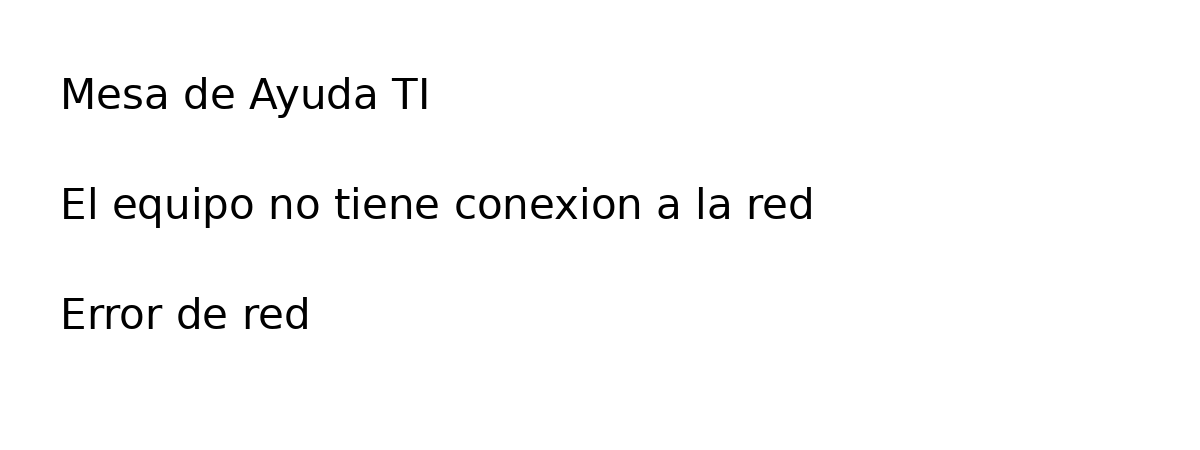


Motor OCR: easyocr
Confianza OCR: 89.69

Texto OCR:
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red

Contenido enviado al modelo:
Solicitud escrita por el usuario:
La conexión presenta un problema según la captura.

Texto extraído de la imagen mediante OCR:
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red

Salida validada:
{
  "categoria": "redes",
  "prioridad": "media",
  "resumen": "Equipo sin conexión a la red, error de red",
  "datos_faltantes": [
    "nombre del equipo o IP",
    "sistema operativo",
    "tipo de conexión (Wi-Fi, Ethernet)",
    "mensaje de error exacto",
    "si otros dispositivos pueden conectarse"
  ],
  "requiere_humano": false,
  "confianza": 0.6
}

Estado: OK_PIDE_ACLARACION
Latencia: 2.1141
Tokens: {'prompt_tokens': 1195, 'completion_tokens': 470, 'total_tokens': 1665}


In [19]:
from IPython.display import display

multimodal_result = None
multimodal_input = None
multimodal_case = {
    "id": "OCR-001",
    "tipo": "multimodal",
    "input": "La conexión presenta un problema según la captura.",
    "expected": {},
}

OCR_ENGINE = "easyocr"

positive_multimodal_path = (
    PROJECT_ROOT / "docs" / "multimodal" / "multimodal_demo.png"
)
positive_multimodal_path.parent.mkdir(parents=True, exist_ok=True)

# Reutilizar la imagen del smoke test como evidencia persistente.
image.save(positive_multimodal_path)

try:
    multimodal_input = prepare_multimodal_input(
        multimodal_case["input"],
        positive_multimodal_path,
        ocr_engine=OCR_ENGINE,
    )

    multimodal_result = run_case(
        multimodal_case,
        multimodal_input=multimodal_input,
    )

    print("=== IMAGEN DE EVIDENCIA ===")
    display(image)

    print("\nMotor OCR:", multimodal_input["extraction"]["engine"])
    print(
        "Confianza OCR:",
        multimodal_input["extraction"]["ocr_confidence"],
    )

    print("\nTexto OCR:")
    print(multimodal_input["extracted_text"])

    print("\nContenido enviado al modelo:")
    print(multimodal_result["user_content_sent"])

    print("\nSalida validada:")
    print(
        json.dumps(
            multimodal_result["validated_output"],
            ensure_ascii=False,
            indent=2,
        )
    )

    print("\nEstado:", multimodal_result["state"])
    print("Latencia:", multimodal_result["latency_seconds"])
    print("Tokens:", multimodal_result["usage"])

except Exception as error:
    print(
        "Demostración multimodal no disponible:",
        error,
    )


## 13. Defensa manual

Esta sección es interactiva y está desactivada por defecto.

Cuando se activa, cada ejecución se registra independientemente mediante `register_defense_case()`. Por tanto, si la consulta se ejecuta `x` veces, las `x` evidencias quedan acumuladas en el mismo PDF.


In [16]:

ENABLE_MANUAL_DEFENSE = False

def select_image() -> str | None:
    from tkinter import Tk, filedialog

    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)

    try:
        selected = filedialog.askopenfilename(
            title="Seleccionar imagen (opcional)",
            filetypes=[
                (
                    "Imágenes",
                    "*.png *.jpg *.jpeg *.webp *.bmp *.tif *.tiff",
                ),
                ("Todos los archivos", "*.*"),
            ],
        )
    finally:
        root.destroy()

    return selected or None


def run_manual_defense() -> list[dict]:
    defense_results = []

    runs = int(input("Número de ejecuciones de defensa: ").strip())

    for execution_number in range(1, runs + 1):
        print(f"\n=== EJECUCIÓN DE DEFENSA {execution_number} ===")

        solicitud = input("Solicitud: ").strip()
        if not solicitud:
            print("Ejecución omitida: solicitud vacía.")
            continue

        selected = select_image()

        manual_input = None
        image_path = None

        if selected:
            image_path = Path(selected)
            manual_input = prepare_multimodal_input(
                solicitud,
                image_path,
                ocr_engine=OCR_ENGINE,
            )

        manual_case = {
            "id": f"DEF-{execution_number:03d}",
            "tipo": "defensa",
            "input": solicitud,
            "expected": {},
        }

        manual_result = run_case(
            manual_case,
            multimodal_input=manual_input,
        )

        defense_results.append({
            "case": manual_case,
            "result": manual_result,
            "image_path": image_path,
        })

        print("\n=== CONTENIDO ENVIADO ===")
        print(manual_result["user_content_sent"])

        print("\n=== SALIDA VALIDADA ===")
        print(
            json.dumps(
                manual_result["validated_output"],
                ensure_ascii=False,
                indent=2,
            )
        )

        print("\n=== ESTADO ===")
        print(manual_result["state"])

        print("\n=== MÉTRICAS ===")
        print("Latencia:", manual_result["latency_seconds"])
        print("Uso:", manual_result["usage"])

    return defense_results


defense_results = []

if ENABLE_MANUAL_DEFENSE:
    defense_results = run_manual_defense()
else:
    print("Demostración manual desactivada.")


Demostración manual desactivada.



## 14. Registro de evidencia y generación del PDF

Todos los casos se registran en una única instancia de `PDFReport`:

- casos reales;
- mocks;
- OCR/multimodalidad;
- cada ejecución de defensa.

La generación se hace al final para que ninguna evidencia posterior quede fuera del documento.


In [17]:

# Casos reales de test.
for case in test_cases:
    result = next(r for r in results if r["case_id"] == case["id"])
    report.register_test_case(
        case=case,
        result=result,
        evaluation=evaluations[result["case_id"]],
    )

# Mocks.
for result in mock_results:
    original_case = next(
        case for case in test_cases
        if case["tipo"] == result["tipo"]
    )
    report.register_case(
        case_id=f"MOCK-{result['tipo']}",
        case_type=result["tipo"],
        input_text=original_case["input"],
        result=result,
        source="mock",
        expected=original_case.get("expected"),
        evaluation=evaluate_case(original_case, result),
    )

# Caso OCR/multimodal.
if multimodal_result is not None and multimodal_input is not None:
    report.register_ocr_case(
        case_id=multimodal_case["id"],
        case_type=multimodal_case["tipo"],
        input_text=multimodal_case["input"],
        result=multimodal_result,
        multimodal=multimodal_input,
        image_path=positive_multimodal_path,
    )

# Todas las ejecuciones de defensa.
for item in defense_results:
    report.register_defense_case(
        case_id=item["case"]["id"],
        input_text=item["case"]["input"],
        result=item["result"],
        multimodal=item["result"].get("multimodal"),
        image_path=item["image_path"],
        notes=f"Ejecución de defensa {item['case']['id']}.",
    )

report_path = report.generate()

print(f"Reporte generado: {report_path}")
print(f"Existe: {report_path.exists()}")
print(f"Casos registrados: {len(report.cases)}")


Reporte generado: /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG/docs/model_results_report.pdf
Existe: True
Casos registrados: 10



## 15. Cierre de la ejecución

El cierre resume únicamente evidencia que fue observada durante el recorrido.


In [18]:

closure = {
    "cinco_casos": len(results) == len(test_cases),
    "salidas_validas": all(r["validated_output"] is not None for r in results),
    "sin_error_tecnico": all(r["state"] != "ERROR_TECNICO" for r in results),
    "sin_error_formato": all(r["state"] != "ERROR_FORMATO" for r in results),
    "ocr_smoke_test": bool(ocr_smoke_results),
    "mocks": bool(mock_results),
    "reporte_pdf": REPORT_PATH.exists(),
}

print("| Evidencia | Resultado |")
print("|---|---|")
for name, value in closure.items():
    print(f"| {name} | {'✅' if value else '⚠️'} |")

print("\nPDF:", REPORT_PATH)
print("Casos en PDF:", len(report.cases))


| Evidencia | Resultado |
|---|---|
| cinco_casos | ✅ |
| salidas_validas | ✅ |
| sin_error_tecnico | ✅ |
| sin_error_formato | ✅ |
| ocr_smoke_test | ✅ |
| mocks | ✅ |
| reporte_pdf | ✅ |

PDF: /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG/docs/model_results_report.pdf
Casos en PDF: 10



## Limitaciones

- Los cinco casos constituyen un smoke test, no una medición estadística de exactitud universal.
- Un JSON válido no garantiza corrección semántica.
- `confianza` del modelo no es una probabilidad calibrada.
- La confianza del OCR es independiente de la confianza de clasificación.
- OCR puede cometer errores sobre texto técnico y capturas complejas.
- La ejecución del proveedor y de EasyOCR/Tesseract depende del entorno configurado.
- Las consultas de defensa dependen de interacción manual cuando esa sección se habilita.
